In [47]:
import pypsa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import tempfile

# ==========================================
# 0. Environment and Path Configuration
# ==========================================
# Defining a temporary directory for solver files to avoid permission issues
safe_temp_dir = r"C:\PyPSA_Temp" 

if not os.path.exists(safe_temp_dir):
    os.makedirs(safe_temp_dir)

os.environ['TMPDIR'] = safe_temp_dir
os.environ['TEMP'] = safe_temp_dir
os.environ['TMP'] = safe_temp_dir
tempfile.tempdir = safe_temp_dir

script_dir = os.getcwd() 
os.chdir(script_dir)

# ==========================================
# 1. Initialize Network and Snapshots
# ==========================================
n = pypsa.Network()

# Hourly snapshots for a full year (8760 hours)
snapshots = pd.date_range("2017-01-01 00:00", "2017-12-31 23:00", freq="H")
n.set_snapshots(snapshots)

# ==========================================
# 2. Build Multi-node Topology (Buses)
# ==========================================
countries = ["DE", "FR", "AT", "CH"]

# Add buses with a nominal voltage of 400 kV
for c in countries:
    n.add("Bus", c, v_nom=400)

# ==========================================
# 3. Add Interconnectors (HVAC Lines)
# ==========================================
interconnectors = {
    "AT-CH": {"bus0": "AT", "bus1": "CH", "s_nom": 2152.75},
    "AT-DE": {"bus0": "AT", "bus1": "DE", "s_nom": 4232.10},
    "CH-DE": {"bus0": "CH", "bus1": "DE", "s_nom": 7106.32},
    "CH-FR": {"bus0": "CH", "bus1": "FR", "s_nom": 2926.94},
    "DE-FR": {"bus0": "DE", "bus1": "FR", "s_nom": 4120.00}
}

for name, params in interconnectors.items():
    n.add("Line", name,
          bus0=params["bus0"],
          bus1=params["bus1"],
          s_nom=params["s_nom"],           # Fixed interconnection capacity
          s_nom_extendable=False,          # Disable capacity expansion for cross-border lines
          x=0.1)                           # Key parameter: Per-unit reactance

# ==========================================
# 4. Generator Configuration for Joint Optimization
# ==========================================

# ADD THIS BLOCK — Define carriers with CO2 intensities (t_CO2 / MWh_el)
n.add("Carrier", "Wind Onshore",                    co2_emissions=0.0)
n.add("Carrier", "Solar",                           co2_emissions=0.0)
n.add("Carrier", "Fossil Gas",                      co2_emissions=0.19)
n.add("Carrier", "Fossil Hard coal",                co2_emissions=0.34)
n.add("Carrier", "Nuclear",                         co2_emissions=0.0)
n.add("Carrier", "Hydro Run-of-river and pondage",  co2_emissions=0.0)
n.add("Carrier", "Hydro Water Reservoir",           co2_emissions=0.0)
n.add("Carrier", "Hydro Pumped Storage",            co2_emissions=0.0)

country_techs = {
    "DE": ["Wind Onshore", "Solar", "Fossil Hard coal", "Fossil Gas"], 
    "FR": ["Wind Onshore", "Solar", "Fossil Gas", "Nuclear"],
    "CH": ["Wind Onshore", "Solar", "Hydro Run-of-river and pondage", "Hydro Water Reservoir", "Hydro Pumped Storage"],
    "AT": ["Wind Onshore", "Solar", "Fossil Gas", "Hydro Run-of-river and pondage", "Hydro Water Reservoir", "Hydro Pumped Storage"]
}

costs = {
    "Wind Onshore": {"capital_cost": 103363.0, "marginal_cost": 0.01},
    "Solar": {"capital_cost": 49219.0, "marginal_cost": 0.01},
    "Fossil Gas": {"capital_cost": 66534.0, "marginal_cost": 55.38},      
    "Hydro Run-of-river and pondage": {"capital_cost": 270930.0, "marginal_cost": 0.01},
    "Hydro Water Reservoir": {"capital_cost": 160620.0, "marginal_cost": 0.01},
    "Fossil Hard coal": {"capital_cost": 135000.0, "marginal_cost": 40.0},
    "Nuclear": {"capital_cost": 450000.0, "marginal_cost": 12.0},
    "Hydro Pumped Storage": {"capital_cost": 160000.0, "marginal_cost": 2.0}
}

# List of Variable Renewable Energy Sources (VRES) requiring availability profiles (p_max_pu)
vres_techs = ["Wind Onshore", "Solar", "Hydro Run-of-river and pondage"]

C:\PyPSA_Temp\ipykernel_20632\3660120391.py:31: FutureWarning:

'H' is deprecated and will be removed in a future version, please use 'h' instead.



In [48]:
def clean_datetime_index(df):
    if not isinstance(df.index, pd.DatetimeIndex):
        time_str = df.index.astype(str)
        # Handle time interval formats containing " - " (e.g., "00:00 - 01:00")
        if time_str.str.contains(' - ').any():
            time_str = time_str.str.split(' - ').str[0]
        # Remove timezone suffixes like " (CET)" or " (CEST)"
        time_str = time_str.str.replace(r'\s*\(.*?\)', '', regex=True)
        # Force parsing using "Day/Month/Year" format
        df.index = pd.to_datetime(time_str, dayfirst=True)
    return df

# Iterate through countries to populate data
for c in countries:
    # 1. Import and process load data
    df_path = os.path.join(script_dir, f"{c}_Load_d).csv") # Ensure filename matches local file naming convention
    load_df = pd.read_csv(df_path, index_col=0)
    load_df = clean_datetime_index(load_df)
    
    # Clean numeric format (remove commas and convert to float)
    load_series = load_df['Actual Total Load (MW)'].astype(str).str.replace(',', '')
    load_series = pd.to_numeric(load_series, errors='coerce')

    # Resample to hourly and align with network snapshots
    hourly_load = load_series.resample('1h').mean()
    hourly_load = hourly_load.reindex(n.snapshots).fillna(0) 

    n.add("Load", f"{c}_load",
          bus=c,
          p_set=hourly_load.values)
    
    # 2. Import generation data and convert to generator units
    df_path = os.path.join(script_dir, f"{c}_Gene_d).csv")
    gene_df = pd.read_csv(df_path, index_col=0) 
    gene_df = clean_datetime_index(gene_df)
    
    for tech in country_techs[c]:
        cost = costs[tech]
        
        tech_df = gene_df[gene_df['Production Type'] == tech]

C:\PyPSA_Temp\ipykernel_20632\1984804814.py:34: DtypeWarning:

Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.



In [49]:
def clean_datetime_index(df):
    if not isinstance(df.index, pd.DatetimeIndex):
        time_str = df.index.astype(str)
        # Handle time interval formats containing " - " (e.g., "00:00 - 01:00")
        if time_str.str.contains(' - ').any():
            time_str = time_str.str.split(' - ').str[0]
        # Remove timezone suffixes like " (CET)" or " (CEST)"
        time_str = time_str.str.replace(r'\s*\(.*?\)', '', regex=True)
        # Force parsing using "Day/Month/Year" format
        df.index = pd.to_datetime(time_str, dayfirst=True)
    return df

# Iterate through countries to populate data
for c in countries:
    # 1. Import and process load data
    df_path = os.path.join(script_dir, f"{c}_Load_d).csv") # Ensure filename matches local file naming convention
    load_df = pd.read_csv(df_path, index_col=0)
    load_df = clean_datetime_index(load_df)
    
    # Clean numeric format (remove commas and convert to float)
    load_series = load_df['Actual Total Load (MW)'].astype(str).str.replace(',', '')
    load_series = pd.to_numeric(load_series, errors='coerce')

    # Resample to hourly and align with network snapshots
    hourly_load = load_series.resample('1h').mean()
    hourly_load = hourly_load.reindex(n.snapshots).fillna(0) 

    n.add("Load", f"{c}_load",
          bus=c,
          p_set=hourly_load.values)
    
    # 2. Import generation data and convert to generator units
    df_path = os.path.join(script_dir, f"{c}_Gene_d).csv")
    gene_df = pd.read_csv(df_path, index_col=0) 
    gene_df = clean_datetime_index(gene_df)
    
    for tech in country_techs[c]:
        cost = costs[tech]
        
        tech_df = gene_df[gene_df['Production Type'] == tech]
        
        if tech_df.empty:
            print(f"⚠️ Warning: No valid generation data found for {tech} in {c} within the CSV.")
            continue
            
        # Also force conversion to numeric format
        gen_series = tech_df['Generation (MW)'].astype(str).str.replace(',', '')
        gen_series = pd.to_numeric(gen_series, errors='coerce')

        tech_gen = gen_series.resample('1h').mean()
        tech_gen = tech_gen.reindex(n.snapshots).fillna(0)
        
        if tech_gen.max() == 0:
            print(f"⚠️ Warning: Annual generation data for {tech} in {c} is zero.")
            continue
            
        # A. Variable Renewable Energy Sources (VRES)
        if tech in vres_techs:
            # Create availability profile (p_max_pu)
            p_max_pu_profile = tech_gen / tech_gen.max()
            p_max_pu_profile = np.clip(p_max_pu_profile.values, 0, 1) 
            
            n.add("Generator", f"{c}_{tech}",
                  bus=c,
                  carrier=tech,
                  p_nom_extendable=True,
                  p_max_pu=p_max_pu_profile,
                  capital_cost=cost["capital_cost"],
                  marginal_cost=cost["marginal_cost"])
                  
        # B. Pumped Hydro Storage (modeled as StorageUnit)
        elif tech == "Hydro Pumped Storage":
            n.add("StorageUnit", f"{c}_{tech}",
                  bus=c,
                  carrier=tech,
                  p_nom_extendable=True,
                  capital_cost=cost["capital_cost"],
                  marginal_cost=cost["marginal_cost"],
                  efficiency_store=0.8,     
                  efficiency_dispatch=0.9,  
                  max_hours=6)              
                  
        # C. Conventional Dispatchable Generators
        else:
            n.add("Generator", f"{c}_{tech}",
                  bus=c,
                  carrier=tech,
                  p_nom_extendable=True,
                  capital_cost=cost["capital_cost"],
                  marginal_cost=cost["marginal_cost"])

# ==========================================
# 5. Run DC Optimal Power Flow (DC OPF)
# ==========================================
print("✅ Model construction complete, including the following components:")
print(n.components)
print("\nSystem ready. Starting joint optimization solver...")

C:\PyPSA_Temp\ipykernel_20632\639025798.py:34: DtypeWarning:

Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.



✅ Model construction complete, including the following components:
PyPSA Components Store
- 4 'Bus' Components
- 8 'Carrier' Components
- 17 'Generator' Components
- 4 'Load' Components
- 0 'Link' Components
- 0 'Store' Components
- 2 'StorageUnit' Components
- 5 'Line' Components
- 59 'LineType' Components
- 0 'Transformer' Components
- 14 'TransformerType' Components
- 0 'ShuntImpedance' Components
- 0 'GlobalConstraint' Components
- 0 'Shape' Components
- 0 'SubNetwork' Components

System ready. Starting joint optimization solver...


In [50]:
# ==========================================
# 5.2 Set CO2 Constraint
# ==========================================
baseline_emissions = 107.4e6  # tonnes, from your unconstrained run
co2_limit = baseline_emissions * 0.50  # 50% reduction

n.add("GlobalConstraint",
      "co2_limit",
      carrier_attribute="co2_emissions",
      sense="<=",
      constant=co2_limit)

In [51]:
# ==========================================
# Operational Optimization: Linear Power Flow (DC Approximation) based on Kirchhoff's Laws
# ==========================================
status, condition = n.optimize(solver_name="gurobi") # Change solver_name if using open-source solvers like glpk or cbc
print(f"Optimization Status: {status}")

# Extract CO2 results
# if status == "ok":
#     co2_price = n.global_constraints.loc["co2_limit", "mu"]
#     print(f"CO2 shadow price: {co2_price:.2f} €/tCO2")

Index(['DE', 'FR', 'AT', 'CH'], dtype='object', name='name')
Index(['AT-CH', 'AT-DE', 'CH-DE', 'CH-FR', 'DE-FR'], dtype='object', name='name')
Index(['AT-CH', 'AT-DE', 'CH-DE', 'CH-FR', 'DE-FR'], dtype='object', name='name')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 7/7 [00:00<00:00, 150.65it/s]
INFO:linopy.io: Writing time: 0.87s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2775732


INFO:gurobipy:Set parameter LicenseID to value 2775732


...

Solved in 58043 iterations and 21.02 seconds (28.90 work units)


INFO:gurobipy:Solved in 58043 iterations and 21.02 seconds (28.90 work units)


Optimal objective  5.782610456e+10


INFO:gurobipy:Optimal objective  5.782610456e+10
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 245299 primals, 560660 duals
Objective: 5.78e+10
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper, Line-fix-s-lower, Line-fix-s-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, Kirchhoff-Voltage-Law, StorageUnit-energy_balance were not assigned to the network.


Optimization Status: ok


In [52]:
# Extract Results

if status == "ok":
    print("\n--- Optimized Interconnector Configuration and Loading Factors ---")
    # Calculate the average loading rate of the lines
    loading = (n.lines_t.p0.abs().mean() / n.lines.s_nom) * 100
    print(loading.round(2).astype(str) + " %")

# ==========================================
# 6. Data Extraction (Preparation for subsequent sections)
# ==========================================
if status == "ok":
    print("\n--- Overview of the total power flow of the interconnected lines ---")
    print(n.lines_t.p0.describe())
    
    print("\n--- Optimized generator capacity of each node (in MW) ---")
    print(n.generators.p_nom_opt)
    
    # Get the power flow at the first time step; this is the benchmark for manual PTDF verification in part e)
    print("\n--- Line power at the first time step (MW) ---")
    first_step_flows = n.lines_t.p0.iloc[0]
    print(first_step_flows)
    
    # Save nodal power imbalances (Generation - Demand) at the first time step for part e)
    first_step_imbalance = (n.generators_t.p.iloc[0].groupby(n.generators.bus).sum() 
                            - n.loads_t.p_set.iloc[0].groupby(n.loads.bus).sum())
    print("\n--- Nodal power injection/imbalance at the first time step (MW) ---")
    print(first_step_imbalance)


--- Optimized Interconnector Configuration and Loading Factors ---
name
AT-CH    90.31 %
AT-DE    87.18 %
CH-DE    74.48 %
CH-FR    96.55 %
DE-FR    77.99 %
dtype: object

--- Overview of the total power flow of the interconnected lines ---
name         AT-CH        AT-DE        CH-DE        CH-FR        DE-FR
count  8760.000000  8760.000000  8760.000000  8760.000000  8760.000000
mean  -1419.340162  3668.936986  5088.277148  2808.257925 -2280.019223
std    1402.240725  1208.565835  2417.845158   423.598384  2438.162842
min   -2152.750000 -2143.772325 -2180.737494 -2926.940000 -4120.000000
25%   -2152.750000  4232.100000  5540.091250  2926.940000 -3457.910000
50%   -2152.750000  4232.100000  6384.850000  2926.940000 -3457.910000
75%   -1606.169003  4232.100000  6384.850000  2926.940000 -2661.350357
max    2152.750000  4232.100000  6384.850000  2926.940000  4120.000000

--- Optimized generator capacity of each node (in MW) ---
name
DE_Wind Onshore                      82370.889226
DE_So

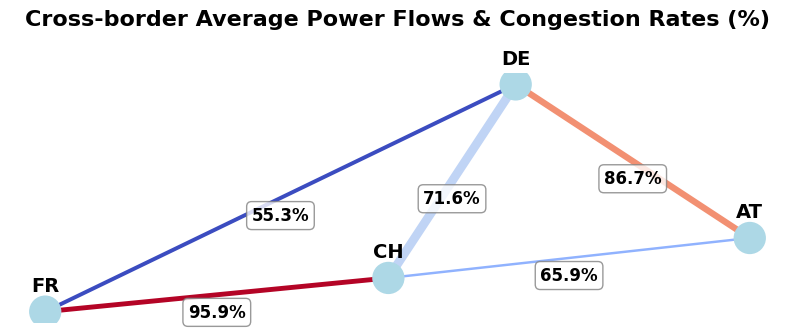

In [53]:
import matplotlib.pyplot as plt

n.buses.loc["DE", ["x", "y"]] = [10.45, 50.2] 
n.buses.loc["FR", ["x", "y"]] = [2.21, 46.22]
n.buses.loc["CH", ["x", "y"]] = [8.22, 46.81]
n.buses.loc["AT", ["x", "y"]] = [14.55, 47.51]

mean_flow = n.lines_t.p0.mean().abs() 
loading = (mean_flow / n.lines.s_nom) * 100 

fig, ax = plt.subplots(figsize=(10, 8))

n.plot(
    ax=ax,
    geomap=False,
    bus_sizes=0.08,                        
    bus_colors="lightblue",                
    line_colors=loading,                   
    line_cmap=plt.cm.coolwarm,             
    line_widths=mean_flow / 800,           
    title="Cross-border Average Power Flows & Congestion Rates (%)"
)

plt.title("Cross-border Average Power Flows & Congestion Rates (%)", 
          y=1.05, fontsize=16, fontweight='bold', pad=25)

y_offset_line_labels = -0.15 
for line_name, line in n.lines.iterrows():
    bus0 = n.buses.loc[line.bus0]
    bus1 = n.buses.loc[line.bus1]
    
    x_pos = (bus0.x + bus1.x) / 2
    y_pos = (bus0.y + bus1.y) / 2 + y_offset_line_labels 
    
    ax.text(x_pos, y_pos, f"{loading[line_name]:.1f}%", 
            fontsize=12, fontweight='bold', ha='center', va='top', 
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray', boxstyle='round,pad=0.3'))
    
y_offset_bus_labels = 0.35 
for bus_name, bus in n.buses.iterrows():
    ax.text(bus.x, bus.y + y_offset_bus_labels, bus_name, 
            fontsize=14, fontweight='bold', ha='center')

ax.axis('off')



#plt.savefig("final_network_congestion_map.png", dpi=300, bbox_inches='tight')

plt.show()

In [54]:
first_step_flows = n.lines_t.p0.iloc[0]
first_step_imbalance = (n.generators_t.p.iloc[0].groupby(n.generators.bus).sum() 
                        - n.loads_t.p_set.iloc[0].groupby(n.loads.bus).sum())

print(first_step_flows)

name
AT-CH   -2152.75
AT-DE    4232.10
CH-DE    6384.85
CH-FR    2926.94
DE-FR   -3457.91
Name: 2017-01-01 00:00:00, dtype: float64


In [55]:
# After n.optimize(), compute total system emissions

emissions_per_carrier = n.carriers["co2_emissions"]  # t/MWh
gen_by_carrier = n.generators_t.p.groupby(n.generators.carrier, axis=1).sum()
total_emissions = (gen_by_carrier * emissions_per_carrier).sum().sum()
print(f"Baseline emissions: {total_emissions/1e6:.1f} Mt CO2")

if status == "ok":
    co2_price = n.global_constraints.loc["co2_limit", "mu"]
    print(f"CO2 shadow price: {co2_price:.2f} €/tCO2")

Baseline emissions: 53.7 Mt CO2
CO2 shadow price: -97.94 €/tCO2


C:\PyPSA_Temp\ipykernel_20632\2689302941.py:4: FutureWarning:

DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.



In [17]:
# ==========================================
# Task h) - CO2 Shadow Price Sensitivity Analysis
# ==========================================

baseline_emissions = 107.4e6
reduction_steps = np.arange(0, 110, 10)
shadow_prices = []
actual_emissions = []
system_costs = []

n.model.solver_model = None

for red_pct in reduction_steps:
    print(f"Running {red_pct}% reduction...", end=" ", flush=True)
    
    n_temp = n.copy()
    co2_cap = baseline_emissions * (1 - red_pct / 100)
    
    if "co2_limit" in n_temp.global_constraints.index:
        n_temp.remove("GlobalConstraint", "co2_limit")
    
    if red_pct > 0:
        n_temp.add("GlobalConstraint",
                   "co2_limit",
                   carrier_attribute="co2_emissions",
                   sense="<=",
                   constant=co2_cap)
    
    status, _ = n_temp.optimize(solver_name="gurobi",
                                 solver_options={"OutputFlag": 0})
    
    if status == "ok" and red_pct > 0:
        mu = n_temp.global_constraints.loc["co2_limit", "mu"]
        cost = n_temp.objective / 1e9  # in Billion €
        shadow_prices.append(abs(mu))
        actual_emissions.append(co2_cap / 1e6)
        system_costs.append(cost)
        print(f"✅ Shadow price: {abs(mu):.2f} €/tCO2 | Cost: {cost:.2f} B€")
    elif status == "ok" and red_pct == 0:
        cost = n_temp.objective / 1e9
        shadow_prices.append(0.0)
        actual_emissions.append(baseline_emissions / 1e6)
        system_costs.append(cost)
        print(f"✅ No constraint | Cost: {cost:.2f} B€")
    else:
        shadow_prices.append(np.nan)
        actual_emissions.append(co2_cap / 1e6)
        system_costs.append(np.nan)
        print(f"❌ Infeasible!")

Running 0% reduction... 

Index(['DE', 'FR', 'AT', 'CH'], dtype='object', name='name')
Index(['AT-CH', 'AT-DE', 'CH-DE', 'CH-FR', 'DE-FR'], dtype='object', name='name')
Index(['AT-CH', 'AT-DE', 'CH-DE', 'CH-FR', 'DE-FR'], dtype='object', name='name')
Index(['0'], dtype='object', name='name')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.model:Solver options:
 - OutputFlag: 0
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 7/7 [00:00<00:00, 142.25it/s]
INFO:linopy.io: Writing time: 0.84s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2775732


...

Reading time = 1.05 seconds


INFO:gurobipy:Reading time = 1.05 seconds


obj: 560660 rows, 245299 columns, 1113790 nonzeros


INFO:gurobipy:obj: 560660 rows, 245299 columns, 1113790 nonzeros
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 245299 primals, 560660 duals
Objective: 1.00e+12
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper, Line-fix-s-lower, Line-fix-s-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, Kirchhoff-Voltage-Law, StorageUnit-energy_balance were not assigned to the network.


✅ Shadow price: 108556866.72 €/tCO2 | Cost: 999.57 B€


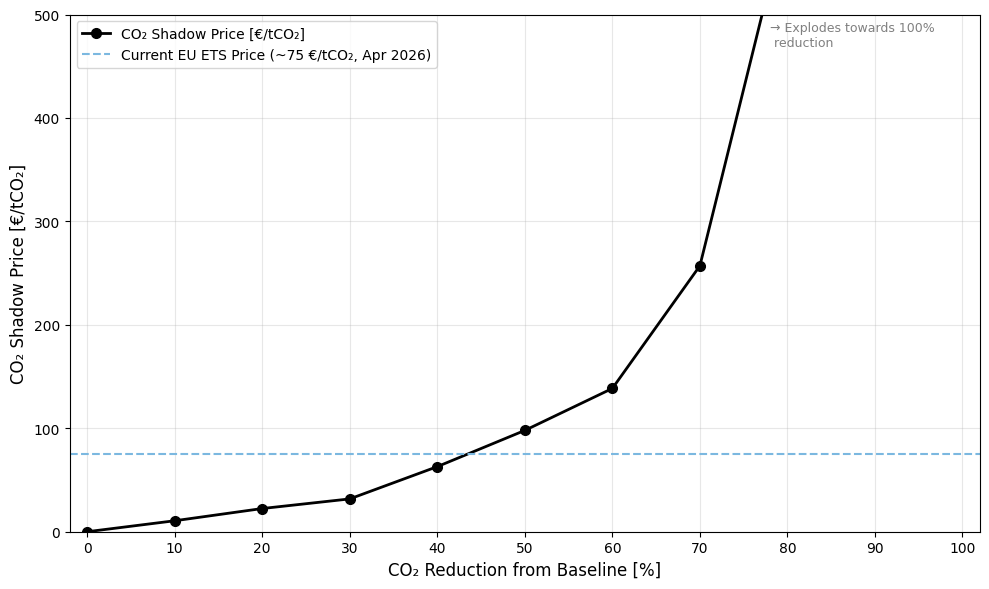

In [37]:
# ==========================================
# Plot: Shadow Price vs CO2 Reduction (%)
# ==========================================

# Convert emissions to reduction percentage
plot_reductions = [(1 - e / (baseline_emissions / 1e6)) * 100 for e in actual_emissions[:-1]]
plot_prices     = shadow_prices[:-1]

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(plot_reductions, plot_prices, 'o-', color='black',
        linewidth=2, markersize=7, label='CO₂ Shadow Price [€/tCO₂]')

# Cap y-axis at 500 €/tCO2
ax.set_ylim(0, 500)

# Annotation for explosion above 500
ax.annotate('→ Explodes towards 100% \n reduction',
            xy=(78, 470), fontsize=9, color='gray')

# Current EU ETS price (April 2026: ~75 €/tCO2)
ets_price = 75
ax.axhline(y=ets_price, color='#7BB8E0', linestyle='--', linewidth=1.5,
           label=f'Current EU ETS Price (~{ets_price} €/tCO₂, Apr 2026)')



ax.set_xlabel("CO₂ Reduction from Baseline [%]", fontsize=12)
ax.set_ylabel("CO₂ Shadow Price [€/tCO₂]", fontsize=12)
#ax.set_title("CO₂ price ", fontsize=14, fontweight='bold')

ax.set_xticks(np.arange(0, 110, 10))
ax.set_xlim(-2, 102)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig("co2_shadow_price_sensitivity.png", dpi=300, bbox_inches='tight')
plt.show()